In [58]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict , Literal  , Union , List , Optional
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel , Field
from datetime import datetime
import pytz
load_dotenv()


True

In [59]:
class ShopQuick(TypedDict):
    cart_amount: float
    is_member: bool
    total_with_tax: float
    final_price: float
    discount_applied: int
    receipt: str



In [60]:
def apply_tax(state: ShopQuick) -> ShopQuick:
    state["total_with_tax"] = state["cart_amount"] * 1.18
    return state


In [61]:
def check_discount(state: ShopQuick) -> ShopQuick:
    price = state["total_with_tax"]
    state["discount_applied"] = 0

    if state["is_member"]:
        price -= price * 0.10
        state["discount_applied"] += 10

    if state["total_with_tax"] > 200000:
        price -= price * 0.05
        state["discount_applied"] += 5

    state["final_price"] = price
    return state


In [63]:
def generate_receipt(state: ShopQuick) -> ShopQuick:
    india_tz = pytz.timezone("Asia/Kolkata")
    current_time = datetime.now(india_tz)
    timenow = current_time.strftime("%d-%m-%Y %H:%M:%S").split()

    state["receipt"] = f"Date- {timenow[0]}\nat {timenow[1]} \nOrder Confirmed! Final amount to pay: Rs{state['final_price']:.2f}"
    return state


In [64]:
graph = StateGraph(ShopQuick)

graph.add_node("apply_tax", apply_tax)
graph.add_node("check_discount", check_discount)
graph.add_node("generate_receipt", generate_receipt)

graph.set_entry_point("apply_tax")
graph.add_edge("apply_tax", "check_discount")
graph.add_edge("check_discount", "generate_receipt")
graph.add_edge("generate_receipt", END)


workflow = graph.compile()


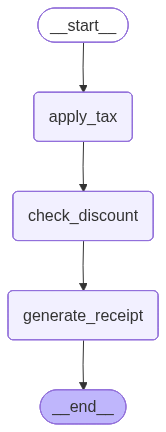

In [65]:
workflow


In [66]:
initial_state = {
    "cart_amount": 1000,
    "is_member": True,
    "total_with_tax": 0,
    "final_price": 0,
    "discount_applied": 0,
    "receipt": ""
}

final_state = workflow.invoke(initial_state)


In [67]:
final_state


{'cart_amount': 1000,
 'is_member': True,
 'total_with_tax': 1180.0,
 'final_price': 1062.0,
 'discount_applied': 10,
 'receipt': 'Date- 01-01-2026\nat 22:01:07 \nOrder Confirmed! Final amount to pay: Rs1062.00'}

In [68]:
print(final_state["receipt"])


Date- 01-01-2026
at 22:01:07 
Order Confirmed! Final amount to pay: Rs1062.00
